# 2. Preprocess normalized data to remove noise.
This works well when data is very noisy or has complicated shapes.
## 2-1. Load Data

In [62]:
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
from pinn.cryoet_io import open_mrc, save_mrc
import napari
from pinn.plot import napari_view, napari_gradient
from pinn.plot import visualize_zyx_midslice, visualize_zyx_midslice_vs_overlay

import numpy as np
import skimage

# data_dir = "synthetic"
data_dir = "Testing"
# shape = "biconcave"
shape = "62_aretomo1_sart_bin4"

normalized_path = f"../data/{data_dir}/{shape}.mrc"
norm_data = open_mrc(normalized_path)

Data shape: (151, 326, 426)
Voxel size (angstroms): (1.0, 1.0, 1.0)


In [67]:
napari_view(norm_data, None)

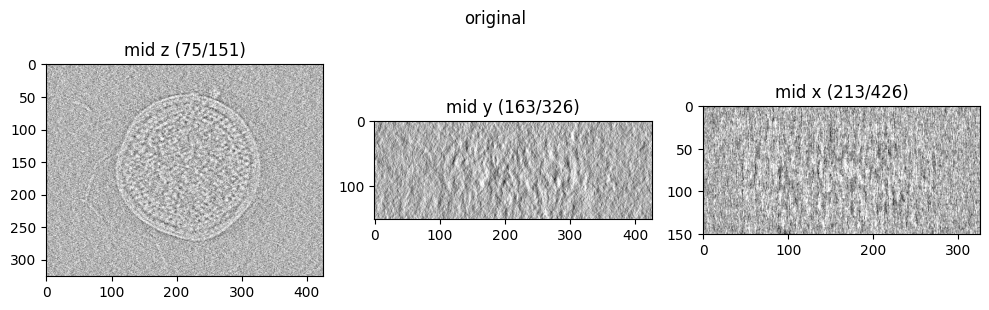

In [63]:
norm_data = -norm_data # Only if the data is not inverted already!
visualize_zyx_midslice(norm_data, title="original")

#### Dilate and save data
Do not run this if you're not trying to dilate the data. Goto 2-2.

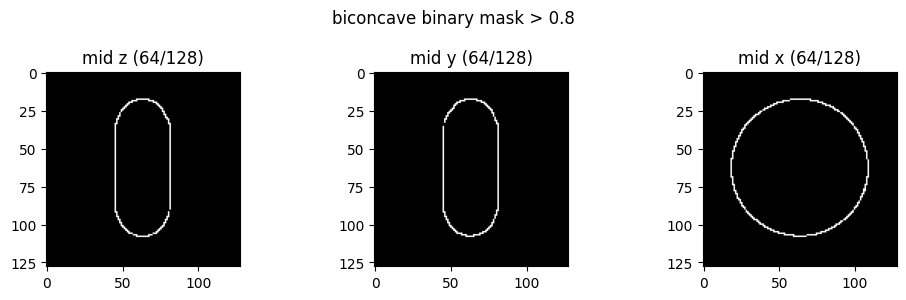

In [33]:
ori_mask = np.where(norm_data > 0.8, 1, 0)
ori_mask = ori_mask.transpose(2,1,0)

visualize_zyx_midslice(ori_mask, "biconcave binary mask > 0.8")

path1 = f"../data/{data_dir}/{shape}_binarized.mrc"
save_mrc(path1, ori_mask)

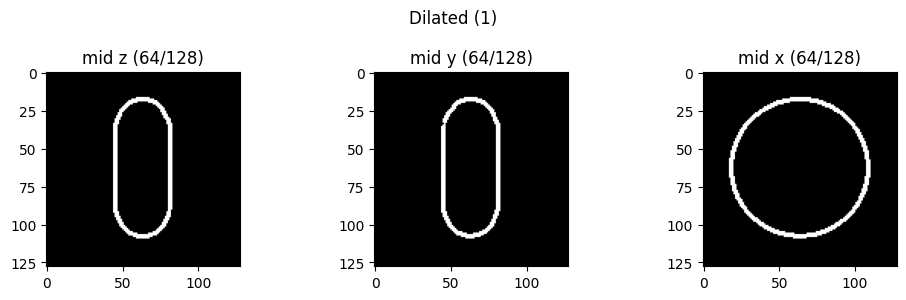

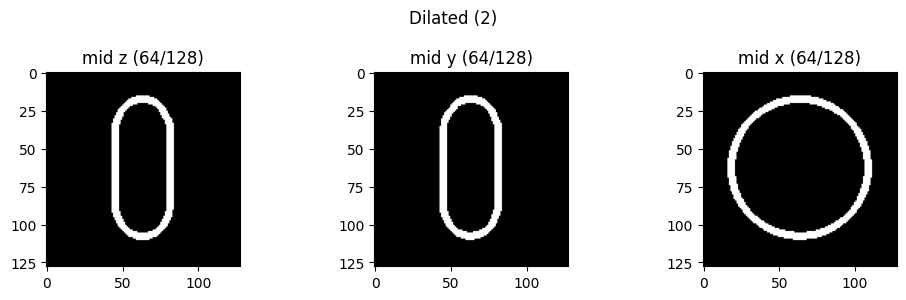

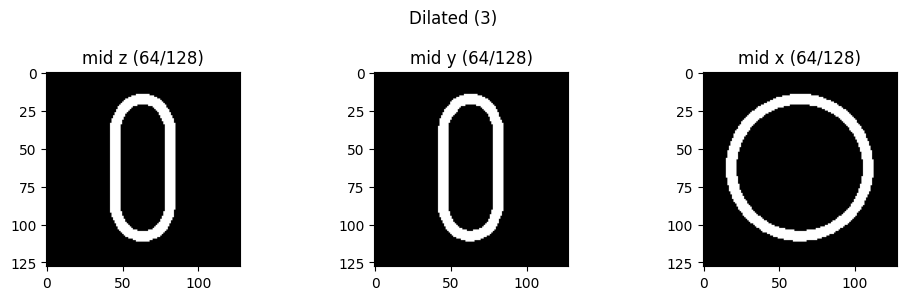

In [36]:
from skimage.morphology import ball, binary_dilation
ori_dilated1 = binary_dilation(ori_mask, ball(1))
visualize_zyx_midslice(ori_dilated1, "Dilated (1)")
path1 = f"../data/{data_dir}/{shape}_binarized_dilated1.mrc"
save_mrc(path1, ori_dilated1)

ori_dilated2 = binary_dilation(ori_mask, ball(2))
visualize_zyx_midslice(ori_dilated2, "Dilated (2)")
path2 = f"../data/{data_dir}/{shape}_binarized_dilated2.mrc"
save_mrc(path2, ori_dilated2)

ori_dilated3 = binary_dilation(ori_mask, ball(3))
visualize_zyx_midslice(ori_dilated3, "Dilated (3)")
path3 = f"../data/{data_dir}/{shape}_binarized_dilated3.mrc"
save_mrc(path3, ori_dilated3)

## 2-2. Preprocessing pipeline

### Bandpass Filtering

In [ ]:
from scipy.fft import fftn, ifftn, fftshift
import numpy as np
# Simple bandpass filter where you adjust low and high filter parameters (0~1)
def bandpass_filter_3d(vol, low, high):
    F = fftshift(fftn(vol))
    nx, ny, nz = vol.shape
    X, Y, Z = np.ogrid[-nx//2:nx//2, -ny//2:ny//2, -nz//2:nz//2]
    R = np.sqrt(X**2 + Y**2 + Z**2)
    mask = (R > nx*low) & (R < nx*high)
    return np.real(ifftn(np.fft.ifftshift(F * mask)))

In [64]:
from scipy.fft import fftn, ifftn, fftshift, ifftshift
import numpy as np
# Bandpass filter by pixel size
def bandpass_filter_3d_by_size(vol, min_size=None, max_size=None):
    """
    3D band-pass / low-pass filter where the cutoffs are given in *pixel size*.

    Parameters
    ----------
    vol : ndarray
        Input 3D volume, shape (nx, ny, nz).
    min_size : float or None
        Smallest structure size (in pixels) that you want to preserve.
        - Example: min_size=10 → suppress features smaller than ~10 pixels
          (i.e., remove high-frequency noise).
        - If None, do not apply this high-frequency cutoff.
    max_size : float or None
        Largest structure size (in pixels) that you want to preserve.
        - Example: max_size=100 → suppress very smooth background
          larger than ~100 pixels (i.e., remove very low frequencies).
        - If None, do not apply this low-frequency cutoff.

    Returns
    -------
    filtered : ndarray
        Real part of the inverse FFT of the filtered spectrum.
    """
    # Forward FFT and shift zero frequency to the center
    F = fftshift(fftn(vol))
    nx, ny, nz = vol.shape

    # Frequency index grid centered at zero in each dimension
    X, Y, Z = np.ogrid[-nx//2:nx//2, -ny//2:ny//2, -nz//2:nz//2]
    R = np.sqrt(X**2 + Y**2 + Z**2)  # radial distance in index units

    # Start with a mask that keeps everything
    mask = np.ones_like(R, dtype=bool)

    # Map feature size (in pixels) -> frequency radius in index units:
    #   spatial frequency f = 1 / size  (cycles per pixel)
    #   FFT frequency step ≈ 1 / nx, so index radius R = f * nx = nx / size

    # High-frequency cutoff: remove features smaller than min_size
    if min_size is not None:
        high_cut = nx / float(min_size)   # maximum radius to keep
        mask &= (R <= high_cut)

    # Low-frequency cutoff: remove very large-scale background > max_size
    if max_size is not None:
        low_cut = nx / float(max_size)    # minimum radius to keep
        mask &= (R >= low_cut)

    # Apply mask in Fourier domain
    F_filt = F * mask

    # Inverse shift and inverse FFT back to real space
    vol_filt = np.real(ifftn(ifftshift(F_filt)))
    return vol_filt

Data min: -0.04640869
Data max: 0.0096240435
Normalized data min: 0.0
Normalized data max: 1.0


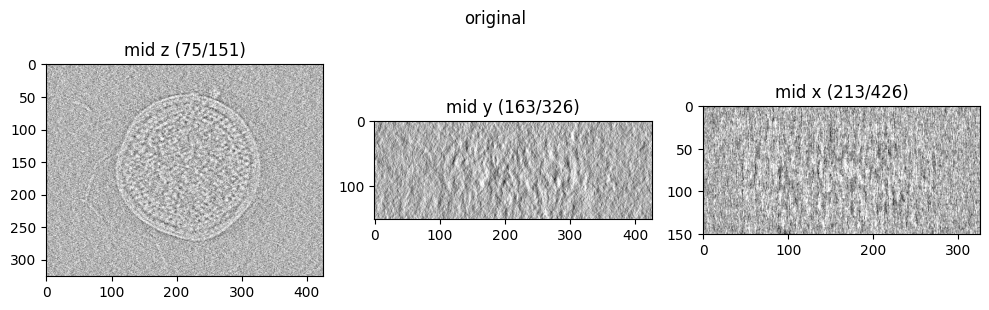

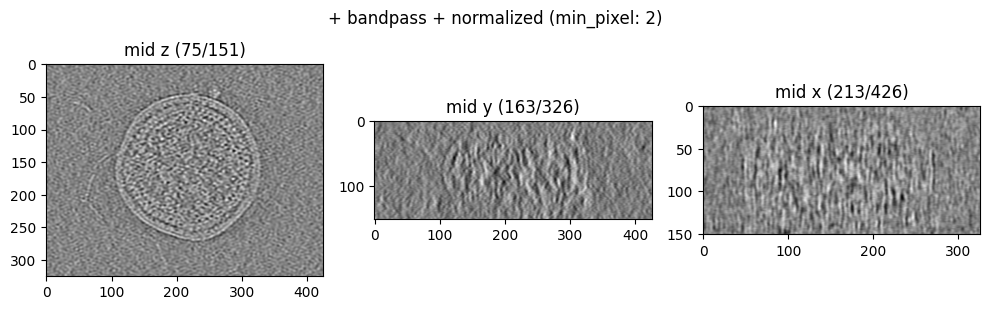

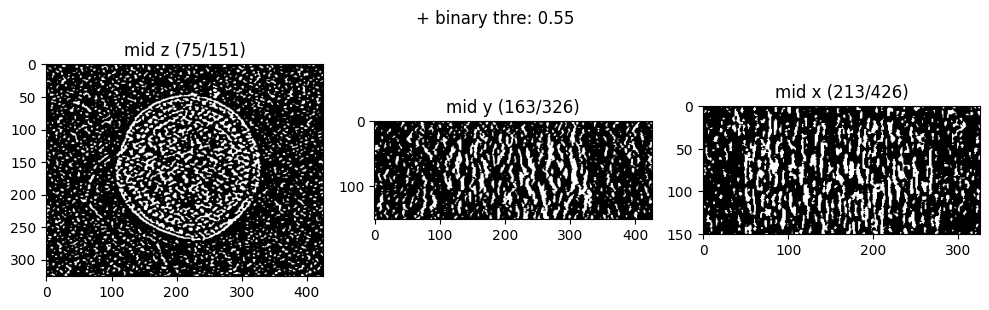

In [93]:
min_pixel = 2
max_pixel = None
thre = 0.55
bandpass = bandpass_filter_3d_by_size(norm_data, min_size=min_pixel, max_size=max_pixel)

# re-normalize after filtering
norm_min, norm_max = 0.0, 1.0
data_min = np.min(bandpass)
data_max = np.max(bandpass)
print("Data min:", data_min)
print("Data max:", data_max)
bandpass_normalized = (bandpass - data_min) / (data_max - data_min)
bandpass_normalized = bandpass_normalized * (norm_max - norm_min) + norm_min
print("Normalized data min:", np.min(bandpass_normalized))
print("Normalized data max:", np.max(bandpass_normalized))

visualize_zyx_midslice(norm_data, title="original")
visualize_zyx_midslice(bandpass_normalized, title=f"+ bandpass + normalized (min_pixel: {min_pixel})")
binary_bandpass = np.where(bandpass_normalized > thre, 1, 0)
visualize_zyx_midslice(binary_bandpass, title=f"+ binary thre: {thre}")

In [72]:
napari_view(norm_data, binary_bandpass)

### Erosion-Dilation

bianry opening = erosion-dilation
binary closing = dilation-erosion

find your best-working combination of 
- binary_closing
- binary_opening
- binary_erosion
- binary_dilation 

Then, remove small objects. You can also use masking to remove large objects.

##### No masking version

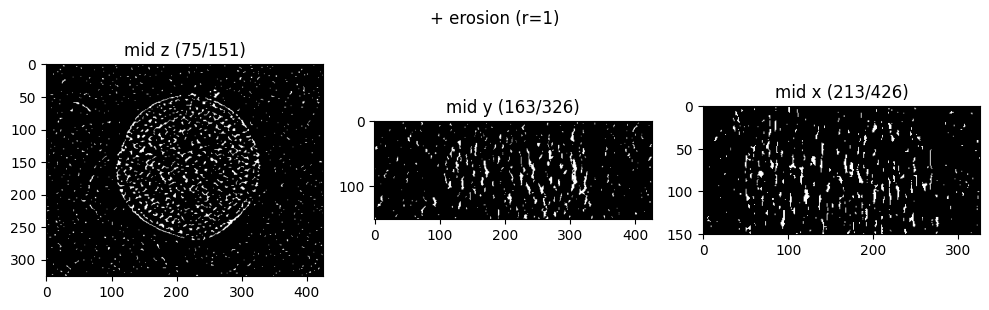

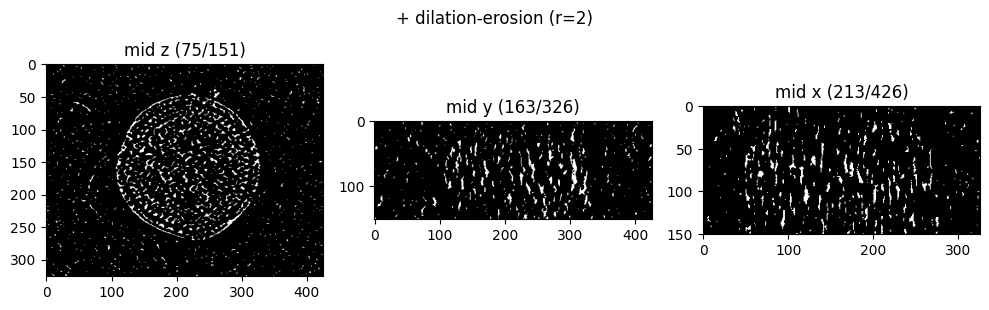

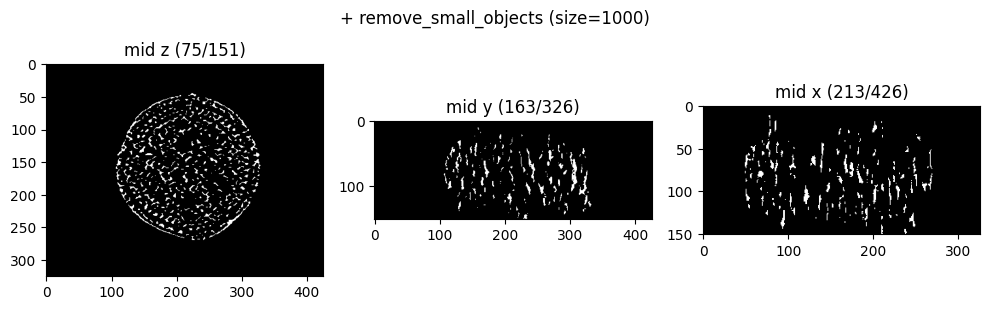

In [94]:
import numpy as np
from skimage.morphology import ball, binary_closing, binary_opening, remove_small_objects, binary_erosion, binary_dilation
from skimage.measure import label

dataR = 2

plane = binary_erosion(binary_bandpass, ball(1))                # removes small speckles
visualize_zyx_midslice(plane, title=f"+ erosion (r={1})")

plane = binary_closing(plane, ball(dataR))                      # connects compontents
visualize_zyx_midslice(plane, title=f"+ dilation-erosion (r={dataR})")

# plane = binary_opening(plane, ball(1))
# visualize_zyx_midslice(plane, title=f"+ erosion-dilation (r={1})")

min_size = 1000
plane = remove_small_objects(plane, min_size=min_size, connectivity=3)
visualize_zyx_midslice(plane, title=f"+ remove_small_objects (size={min_size})")

In [95]:
napari_view(norm_data, plane)

In [96]:
preprocessed_path = f"../data/{data_dir}/{shape}_preprocessed_wo_env.mrc"
save_mrc(preprocessed_path, plane)

##### Yes masking version

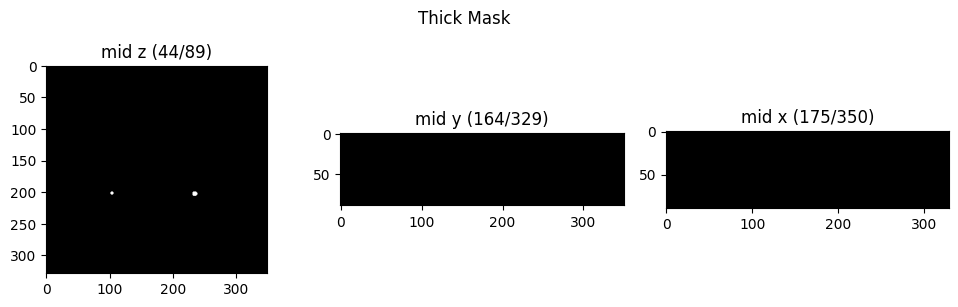

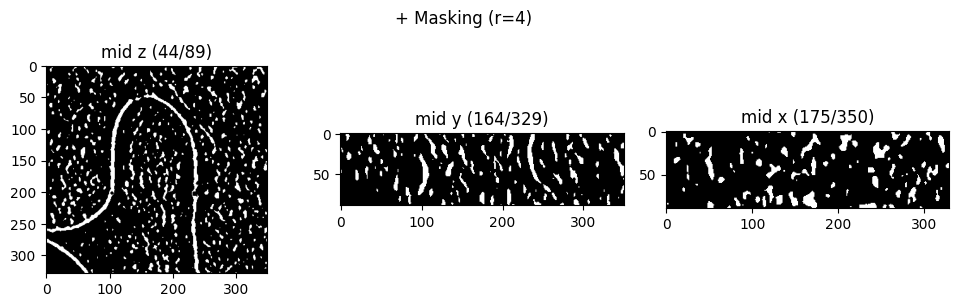

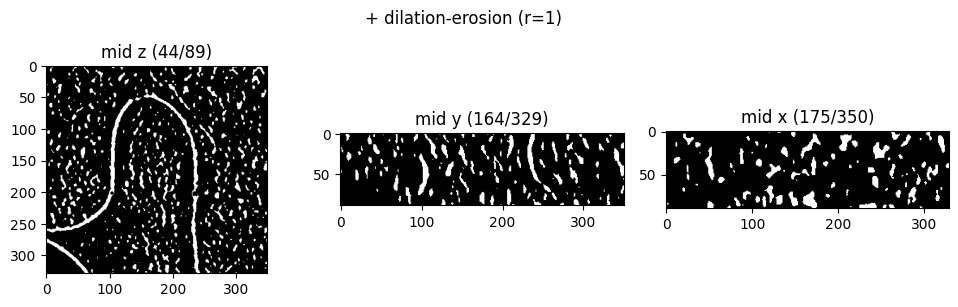

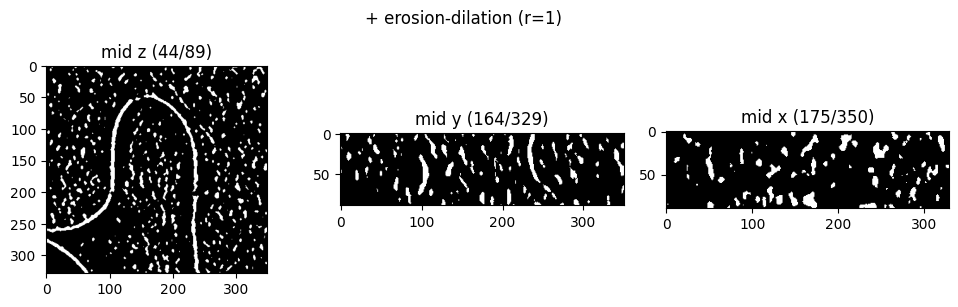

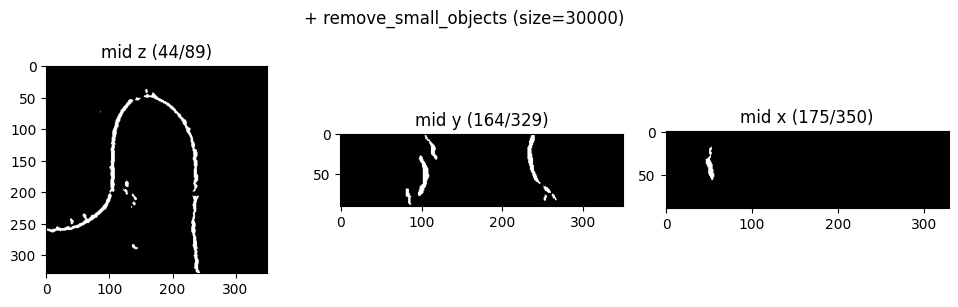

In [17]:
import numpy as np
from skimage.morphology import ball, binary_closing, binary_opening, remove_small_objects, binary_erosion
from skimage.measure import label

# 1. closing: dilation --> erosion / connect / r=1: 3 voxel radius
# 2. opening: erosion --> dilation / remove small particles & noise / use same or smaller r
maskR = 4
thick_mask = binary_opening(binary_bandpass, ball(maskR))
thick_mask = binary_closing(thick_mask, ball(maskR))
visualize_zyx_midslice(thick_mask, title="Thick Mask")

dataR = 1
plane = np.where(thick_mask > 0, 0, binary_bandpass)
visualize_zyx_midslice(plane, title=f"+ Masking (r={maskR})")

plane = binary_closing(plane, ball(dataR))
visualize_zyx_midslice(plane, title=f"+ dilation-erosion (r={dataR})")

plane = binary_opening(plane, ball(dataR))
visualize_zyx_midslice(plane, title=f"+ erosion-dilation (r={dataR})")

min_size = 30000
plane = remove_small_objects(plane, min_size=min_size, connectivity=3)
visualize_zyx_midslice(plane, title=f"+ remove_small_objects (size={min_size})")


In [29]:
napari_view(plane, None)

In [ ]:
preprocessed_path = f"../data/{data_dir}/{shape}_preprocessed.mrc"
save_mrc(preprocessed_path, plane)

# Below is ongoing project for the collaboration with Kelly.
The code is not working correctly.

### Morphology Filtering

In [ ]:
from skimage.morphology import disk

f1 = binary_opening(binary_bandpass, ball(1))
f2 = binary_closing(f1, ball(1))
visualize_zyx_midslice(f1)
visualize_zyx_midslice(f2)

z, _, _ = f2.shape
f3 = f2
for i in range(0, z):
    temp = binary_opening(f2[i,:,:], disk(1))
    temp2 = binary_closing(temp, disk(1))
    f3[i, :, :] = remove_small_objects(temp2, min_size=30, connectivity=2)

visualize_zyx_midslice(f3)
# f4 = binary_opening(f3, ball(1))
f5 = binary_closing(f3, ball(1))
f6 = remove_small_objects(f5, min_size=800, connectivity=3)
# visualize_zyx_midslice(f4)
visualize_zyx_midslice(f6)

lab = label(f6, connectivity=3)
print(lab.max())

In [182]:
viewer = napari.Viewer()
viewer.add_labels(lab, name="Labeled Components", blending="translucent")
napari.run()


In [276]:
napari_gradient(plane)

In [ ]:
from skimage.measure import regionprops
import numpy as np

lab = label(bin3d3, connectivity=3)             # label all 3D structures
keep = np.zeros_like(bin3d3, dtype=bool)        # labels to keep

for r in regionprops(lab):               # for all blobs
    coords = np.array(r.coords)          # all the coords that consists blob
    # if coords.shape[0] < 800:            # size filter (only effective when data wasn't bool)
    #     continue
    X = coords - coords.mean(0)
    C = np.cov(X.T)                      # 3x3 / covariance calculates directionality
    w, _ = np.linalg.eigh(C)             # Eigenvalues in the order of:
    e1, e2, e3 = w[::-1]                 # e1>=e2>=e3
    planarity = (e2 - e3) / (e1 + 1e-8)  # Big when plate
    linearity = (e1 - e2) / (e1 + 1e-8)  # Big when linear
    sphericity = e3 / (e1 + 1e-8)        # Big when sphere
    if (planarity > 0.5) and (linearity < 0.3) and (sphericity < 0.2):
        keep[lab == r.label] = True

bin3d = keep

In [ ]:
import numpy as np
from scipy.ndimage import label as cc_label
import numpy as np
import napari
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

def napari_gradient_from_mask(mask_bool, name="Gradient", colormap="twilight",
                              base=0.2, scale=0.8, power=2.0, opacity=0.5):
    """
    mask_bool : (Z,Y,X) boolean mask
    base/scale: Distance normalization [base, base+scale]
    power     : Weight depending on the distance (higher value means more dramatic change in color)
    """
    mask = mask_bool.astype(np.float32)
    if mask.size == 0 or mask.max() == 0:
        return None, None  # Empty mask

    # Calculate the center
    z0, y0, x0 = np.array(mask.shape) / 2
    zz, yy, xx = np.meshgrid(
        np.arange(mask.shape[0]),
        np.arange(mask.shape[1]),
        np.arange(mask.shape[2]),
        indexing="ij"
    )
    distance = np.sqrt((zz - z0) ** 2 + (yy - y0) ** 2 + (xx - x0) ** 2)
    dmax = distance.max() if distance.max() > 0 else 1.0
    distance_norm = base + scale * (distance / dmax)

    gradient_mask = mask * (distance_norm ** power)
    layer_kwargs = dict(name=name, colormap=colormap, blending="translucent", opacity=opacity)
    return gradient_mask.astype(np.float32), layer_kwargs

def napari_components_from_mask(mask_bool,
                                name="Components",
                                connectivity=3):
    """
    mask_bool : (Z, Y, X) boolean mask
    connectivity : 1 or 2 (3D; 1 = 6-neighborhood, 2 = 26-neighborhood)
    Returns:
      labels : (Z, Y, X) int32, 0 = background, 1..N = each component
      layer_kwargs : kwargs for napari.add_labels
    """
    mask = mask_bool.astype(bool)
    if mask.size == 0 or not mask.any():
        return None, None  

    if connectivity == 1:
        structure = None  # Default 2D (6-neighborhood)
    else:
        structure = np.ones((3, 3, 3), dtype=int)  # 3D (26-neighborhood)

    labels, num = cc_label(mask, structure=structure)
    print(f"# of components: {num}")

    layer_kwargs = dict(name=name)
    return labels.astype(np.int32), layer_kwargs


827
planar: 5
linear: 367
sphereical: 14
other: 441


/tmp/ipykernel_3747/1079811575.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Metric", y="Value", data=df_melted, palette="pastel")
/home/minisemin/anaconda3/envs/pinn/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/minisemin/anaconda3/envs/pinn/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 18.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/minisemin/anaconda3/envs/pinn/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 72.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  wa

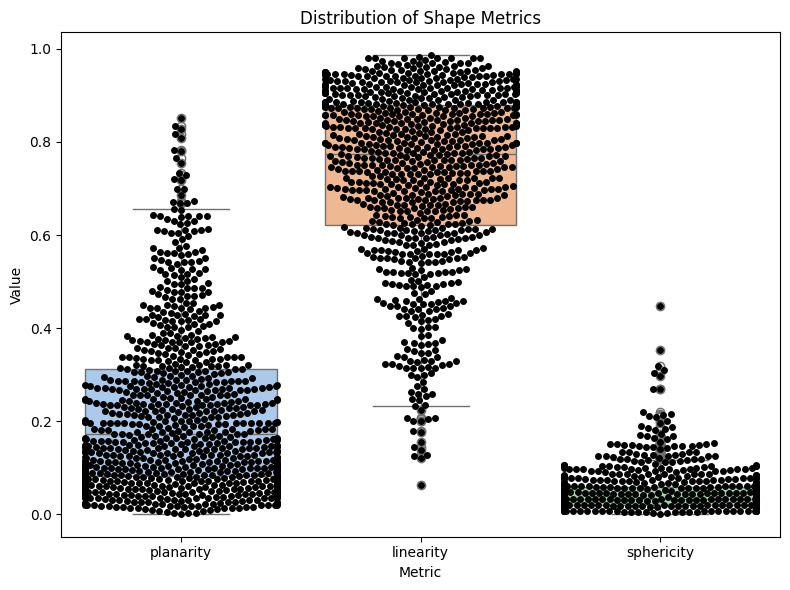

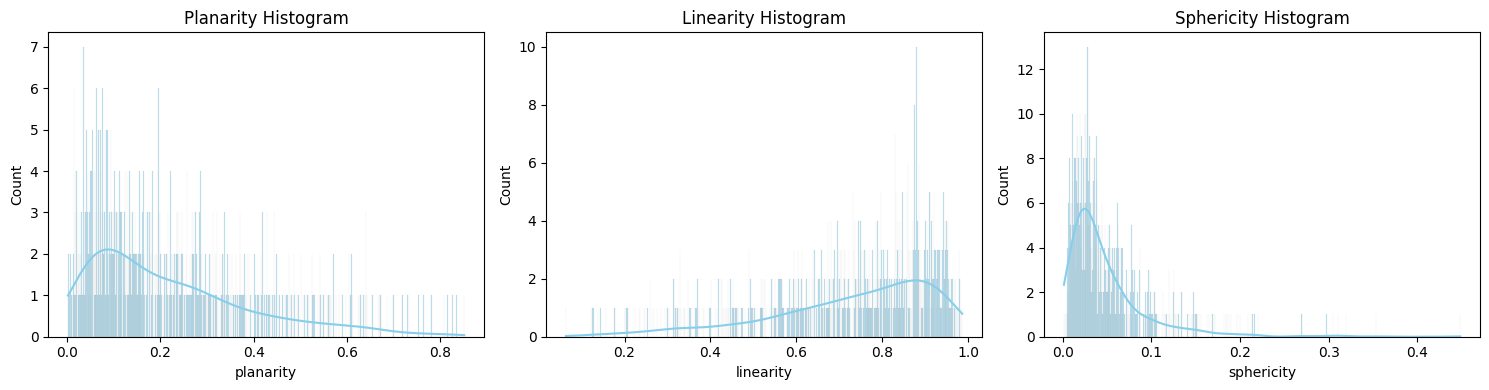

# of components: 5
# of components: 367
# of components: 14
# of components: 441


In [ ]:
# ---------------------------
# 1) blob 분류 + napari 시각화
# ---------------------------
def visualize_by_shape(bin3d,
                       min_size=800,
                       connectivity=3,  # 3D => 26-connectivity(3D)
                       planarity_thr=0.5,
                       linearity_thr=0.3,
                       sphericity_thr=0.2,
                       spacing=None  # (z,y,x) voxel spacing
                       ):
    """
    bin3d: (Z,Y,X) boolean mask
    """
    # Remove too small shapes for safety
    bin3d = remove_small_objects(bin3d.astype(bool), min_size=min_size, connectivity=connectivity)

    # Labeling
    lab = label(bin3d, connectivity=connectivity)
    print(lab.max())

    # Result masks
    planar_mask = np.zeros_like(bin3d, dtype=bool)
    linear_mask = np.zeros_like(bin3d, dtype=bool)
    spherical_mask = np.zeros_like(bin3d, dtype=bool)
    other_mask = np.zeros_like(bin3d, dtype=bool)  # Unsure ones

    planar_cnt = 0
    linear_cnt = 0
    sphere_cnt = 0
    other_cnt = 0

    metrics_dict = {}
    idx = 0
    for r in regionprops(lab):
        coords = np.array(r.coords)  # (N,3) in (z,y,x)

        # spacing
        if spacing is not None:
            coords_scaled = coords * np.array(spacing)[None, :]
        else:
            coords_scaled = coords

        # Covariance + Eigenvalues
        X = coords_scaled - coords_scaled.mean(0)
        C = np.cov(X.T)            # 3x3
        w, _ = np.linalg.eigh(C)   # Order
        e1, e2, e3 = w[::-1]       # e1>=e2>=e3

        # 지표
        eps = 1e-8
        planarity = (e2 - e3) / (e1 + eps)   # plate ↑
        linearity = (e1 - e2) / (e1 + eps)   # line  ↑
        sphericity = (e3) / (e1 + eps)       # sphere↑ (relatively)

        metrics_dict[f"R{idx}"] = {
            "planarity": planarity,
            "linearity": linearity,
            "sphericity": sphericity
        }
        idx += 1

        # Classification rules
        lbl = r.label
        if (planarity > planarity_thr) and (linearity < linearity_thr) and (sphericity < sphericity_thr):
            planar_mask[lab == lbl] = True
            planar_cnt += 1
        elif (linearity > planarity_thr) and (sphericity < sphericity_thr):
            # Linear shape has big e1 and small e2,e3
            linear_mask[lab == lbl] = True
            linear_cnt += 1
        elif (sphericity > sphericity_thr) and (linearity < linearity_thr):
            spherical_mask[lab == lbl] = True
            sphere_cnt += 1
        else:
            other_mask[lab == lbl] = True
            other_cnt += 1        

    print(f"planar: {planar_cnt}")
    print(f"linear: {linear_cnt}")
    print(f"sphereical: {sphere_cnt}")
    print(f"other: {other_cnt}")

    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # dict → DataFrame
    df = pd.DataFrame(metrics_dict).T.reset_index().rename(columns={"index": "Region"})
    df_melted = df.melt(id_vars="Region", var_name="Metric", value_name="Value")

    # Boxplot + swarmplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="Metric", y="Value", data=df_melted, palette="pastel")
    sns.swarmplot(x="Metric", y="Value", data=df_melted, color="black", size=5)
    plt.title("Distribution of Shape Metrics")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, metric in enumerate(["planarity", "linearity", "sphericity"]):
        sns.histplot(df[metric], bins=1000, kde=True, ax=axes[i], color="skyblue")
        axes[i].set_title(f"{metric.capitalize()} Histogram")
    plt.tight_layout()
    plt.show()


    # napari viewer
    viewer = napari.Viewer()

    layers = []

    # arr, kw = napari_gradient_from_mask(planar_mask, name="Planar (plates)", colormap="magma", opacity=0.7)
    # if arr is not None:
    #     viewer.add_image(arr, **kw); layers.append(("planar", arr))
    labels, kw = napari_components_from_mask(planar_mask, name="Planar (plates)")
    if labels is not None:
        viewer.add_labels(labels, **kw)

    # arr, kw = napari_gradient_from_mask(linear_mask, name="Linear (filaments)", colormap="viridis", opacity=0.6)
    # if arr is not None:
    #     viewer.add_image(arr, **kw); layers.append(("linear", arr))
    labels, kw = napari_components_from_mask(linear_mask, name="Linear (filaments)")
    if labels is not None:
        viewer.add_labels(labels, **kw)

    # arr, kw = napari_gradient_from_mask(spherical_mask, name="Spherical (blobs)", colormap="plasma", opacity=0.6)
    # if arr is not None:
    #     viewer.add_image(arr, **kw); layers.append(("spherical", arr))
    labels, kw = napari_components_from_mask(spherical_mask, name="Spherical (blobs)")
    if labels is not None:
        viewer.add_labels(labels, **kw)

    # Comment out if you don't want to see the 'other' category shapes
    # arr, kw = napari_gradient_from_mask(other_mask, name="Other/uncertain", colormap="gray", opacity=0.4)
    # if arr is not None:
    #     viewer.add_image(arr, **kw); layers.append(("other", arr))
    labels, kw = napari_components_from_mask(other_mask, name="Other/uncertain")
    if labels is not None:
        viewer.add_labels(labels, **kw)

    # viewer.add_image(arr, **kw); layers.append(("planar", arr))
    
    viewer.add_image(norm_data.astype(np.float32), name="Center-Distance Gradient", colormap="twilight", blending="translucent", opacity=0.5)

    napari.run()
    return dict(planar=planar_mask, linear=linear_mask, spherical=spherical_mask, other=other_mask)

# ---------------------------
# Example usage
# ---------------------------
result_masks = visualize_by_shape(plane,
                                  min_size=0,
                                  connectivity=3,
                                  planarity_thr=0.8,
                                  linearity_thr=0.8,
                                  sphericity_thr=0.2,
                                  spacing=None)  # e.g., (z_spacing, y_spacing, x_spacing)
